In [1]:
import os
import sys
import numpy as np
import swyft
import pickle
import matplotlib.pyplot as plt
import torch
import importlib
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import LearningRateMonitor
torch.set_float32_matmul_precision('medium')
device_notebook = "cuda" if torch.cuda.is_available() else "cpu"
import wandb
import copy
from torch.multiprocessing import Pool
torch.multiprocessing.set_start_method('spawn',force=True)
torch.set_num_threads(28)
import itertools
import subprocess
from tqdm.auto import tqdm
sys.path.append('/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim')
from explim_functions import generate_expected_limits
from scipy.integrate import trapz

In [2]:
main_dir = "ALPs_with_SWYFT"
thesis_figs = os.getcwd().split(main_dir)[0]+"/"+main_dir+"/thesis_figures/"

In [3]:
names = [
    'flare0_agnostic', 'flare0_semi_informed', 'flare0_informed','flare0_confident1',
    'flare1_agnostic', 'flare1_semi_informed', 'flare1_informed','flare1_confident1',
    'flare2_agnostic', 'flare2_semi_informed', 'flare2_informed','flare2_confident1',
    'flare3_agnostic', 'flare3_semi_informed', 'flare3_informed','flare3_confident1',
]
titles = ["Agnostic Prior", "Semi-Informed Prior", "Informed Prior", "Confident Prior", "CTAO Prior'"]
xlabel = "ALP mass ($m_\mathrm{a}$) / $\mathrm{neV}$"
ylabel = "Photon-ALP coupling ($g_{\mathrm{a}\gamma}$) / $10^{-11} \mathrm{GeV}^{-1}$"
colors_priors = ['r','#FFA500','y','g','b', ]

In [4]:
priors = {}
for ip, name in enumerate(names):

    priors[name] = {'name': name}

    priors[name]['results_path'] = '/home/gertwk/ALPs_with_SWYFT/cluster_runs/analysis_results/'+name

    priors[name]['store_path'] = priors[name]['results_path']+"/sim_output/store"

    priors[name]['config_vars'] = priors[name]['results_path'] +'/config_variables.pickle'

    priors[name]['config_phys'] = priors[name]['results_path'] +'/physics_variables.pickle'
    
    priors[name]['truncation_record'] = priors[name]['results_path'] +'/truncation_record.pickle'

    removed_ALP_sim=0
    try:
        sys.path.remove('/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim')
        removed_ALP_sim=1
    except ValueError:
        pass
    try:
        del sys.modules['ALP_quick_sim']
    except KeyError:
        pass
    try:
        del sys.modules['alp_swyft_simulator']
    except KeyError:
        pass
    sys.path.append(priors[name]['results_path'])
    import param_function
    import ALP_quick_sim
    import alp_swyft_simulator 
    ALP_SWYFT_Simulator = alp_swyft_simulator.ALP_SWYFT_Simulator
    with open(priors[name]['config_vars'], 'rb') as file: config_objects = pickle.load(file)
    for key in config_objects.keys(): priors[name][key] = config_objects[key]
    with open(priors[name]['config_phys'], 'rb') as file: config_objects = pickle.load(file)
    for key in config_objects.keys(): priors[name][key] = config_objects[key]
    with open(priors[name]['truncation_record'], 'rb') as file: config_objects = pickle.load(file)
    for key in config_objects.keys(): priors[name][key] = config_objects[key]
    sys.path.remove(priors[name]['results_path'])
    sys.path.append(priors[name]['results_path']+'/train_output/net')
    import network
    sys.path.remove(priors[name]['results_path']+'/train_output/net')
    
    count = 0
    for combo in itertools.product(*priors[name]['hyperparams'].values()):
        if count == priors[name]['which_grid_point']:
            hyperparams_point = {}
            for i, key in enumerate(priors[name]['hyperparams'].keys()):
                hyperparams_point[key]=combo[i]
        count +=1
        
    priors[name]['net_path'] = (priors[name]['results_path'] + '/train_output/net/trained_network_round_'
                                +str(priors[name]['which_truncation'])+'_gridpoint_'+str(priors[name]['which_grid_point'])+'.pt')

    priors[name]['net'] = network.NetworkCorner(nbins=priors[name]['A'].nbins, marginals=priors[name]['POI_indices'], 
                                                param_names=priors[name]['A'].param_names, **hyperparams_point)

    priors[name]['net'].load_state_dict(torch.load(priors[name]['net_path']))

    same_nuisance_bounds = copy.copy(priors[name]['bounds_rounds'][0][-2])
    A = copy.deepcopy(priors[name]['A'])
    A.configure_model(ALP_seed=0)
    for poi in range(len(same_nuisance_bounds)):
        same_nuisance_bounds[poi] = [priors[name]['obs_params'][poi],priors[name]['obs_params'][poi]]
    priors[name]['same_nuisance_bounds'] = copy.copy(same_nuisance_bounds)
    priors[name]['same_nuisance_sim'] = ALP_SWYFT_Simulator(A, same_nuisance_bounds, priors[name]['prior_funcs'])

    # with open(priors[name]['results_path']+'/explim_predictions.pickle', 'rb') as file:
    #     priors[name]['predictions'] = pickle.load(file)
    
    if priors[name]['which_truncation'] > 0:
        store_explim = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_explim_round_"+str(priors[name]['which_truncation'])+"_gridpoint_"+str(priors[name]['which_grid_point']))
        store_same_nuisance = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_same_nuisance_round_"+str(priors[name]['which_truncation'])+"_gridpoint_"+str(priors[name]['which_grid_point']))
        store_prior = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_prior_round_"+str(priors[name]['which_truncation'])+"_gridpoint_"+str(priors[name]['which_grid_point']))
    else:
        store_explim = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_explim")
        store_same_nuisance = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_same_nuisance")
        store_prior = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_prior")
    priors[name]['samples_explim'] = store_explim.get_sample_store()
    priors[name]['samples_prior'] = store_prior.get_sample_store()
    try:
        priors[name]['samples_same_nuisance'] = store_same_nuisance.get_sample_store()
    except:
        sands = priors[name]['same_nuisance_sim'].get_shapes_and_dtypes()
        store_same_nuisance.init(
            N = 1000,
            chunk_size = 1000,
            shapes=sands[0],
            dtypes=sands[1],
        )
        store_same_nuisance.simulate(priors[name]['same_nuisance_sim'],batch_size = 1000)
        priors[name]['samples_same_nuisance'] = store_same_nuisance.get_sample_store()
 
    del sys.modules['param_function']
    del sys.modules['ALP_quick_sim']
    del sys.modules['alp_swyft_simulator']
    del sys.modules['network']
    if not '/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim' in sys.path: 
        sys.path.append('/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim')

import alp_swyft_simulator 
ALP_SWYFT_Simulator = alp_swyft_simulator.ALP_SWYFT_Simulator


/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packag

In [5]:
trainer = swyft.SwyftTrainer(accelerator = 'cuda', precision = 64,logger=False,)

/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/gertwk/.conda/envs/swyft4-dev-notebook/lib/pyt ...
  rank_zero_warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [6]:
contour_matrices = {}
exclusion_areas = {}

In [7]:
# del sys.modules['explim_functions']
# from explim_functions import generate_expected_limits

In [8]:
colors=['b','g','y','#FFA500','r','k']
line_colors=['b','g','#FFA500','r','b']
linestyles = [':','-.','--','-','-']

/home/gertwk/ALPs_with_SWYFT/cluster_runs/analysis_results/flare1_confident1/ALP_quick_sim.py:476: UserWarning: The number of model parameters, log-indicators, null-hypothesis parameters, parameter names and parameter units are not equal
  warnings.warn("The number of model parameters, log-indicators, null-hypothesis parameters, parameter names and parameter units are not equal")


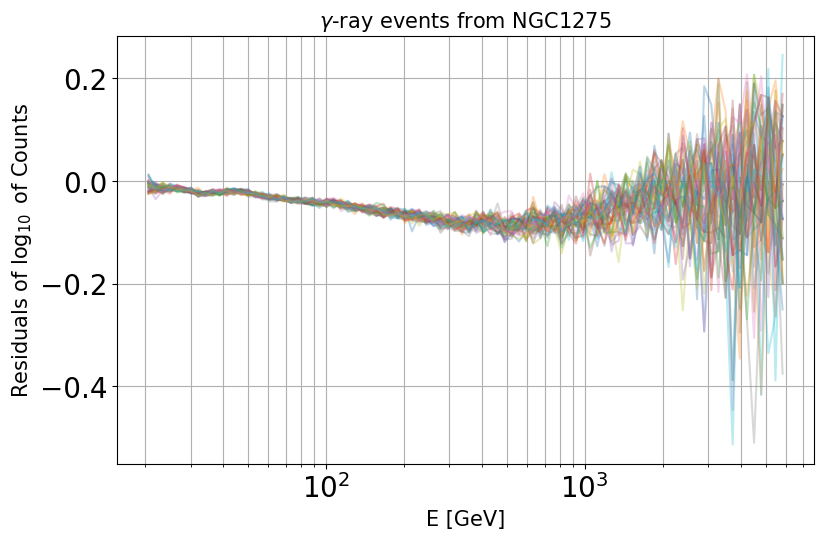

In [9]:
name = 'flare1_confident1'

A = priors[name]['A']

samples = priors[name]['samples_same_nuisance']

A.configure_plot(xmin=None, xmax=None, ymin=None,ymax=None,legend=0, logx=1, logy=0)
for i in range(min(len(samples),50)):
    A.configure_model(params=samples[i]['params'])
    A.import_counts(obs=samples[i]['data'],exp=samples[i]['exp'])
    new_fig = 1 if i==0 else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color=None,color_obs=None,linestyle="-",
                   label_exp=0,label_obs=False, errorbands=False, errors=False, plot_exp=0, transparency=0.7)

/home/gertwk/ALPs_with_SWYFT/cluster_runs/analysis_results/flare1_informed/ALP_quick_sim.py:476: UserWarning: The number of model parameters, log-indicators, null-hypothesis parameters, parameter names and parameter units are not equal
  warnings.warn("The number of model parameters, log-indicators, null-hypothesis parameters, parameter names and parameter units are not equal")


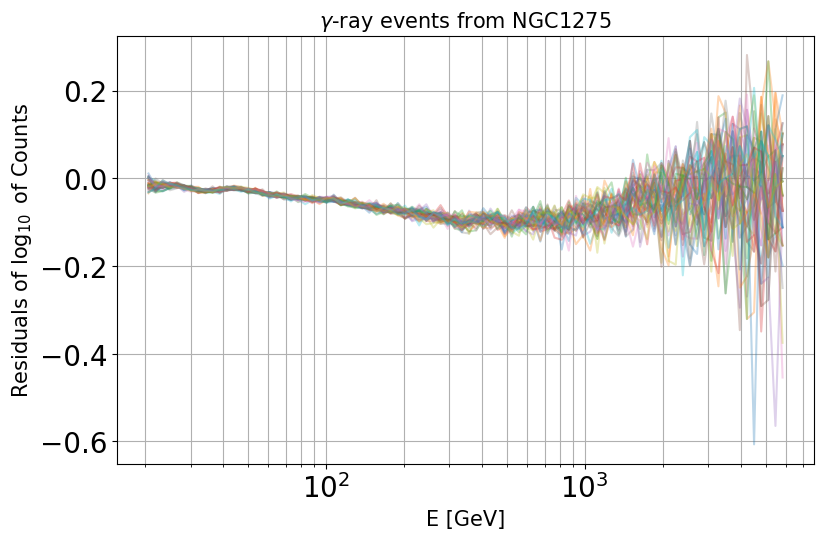

In [10]:
name = 'flare1_informed'

A = priors[name]['A']

samples = priors[name]['samples_same_nuisance']

A.configure_plot(xmin=None, xmax=None, ymin=None,ymax=None,legend=0, logx=1, logy=0)
for i in range(min(len(samples),50)):
    A.configure_model(params=samples[i]['params'])
    A.import_counts(obs=samples[i]['data'],exp=samples[i]['exp'])
    new_fig = 1 if i==0 else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color=None,color_obs=None,linestyle="-",
                   label_exp=0,label_obs=False, errorbands=False, errors=False, plot_exp=0,linestyle_obs='-', transparency=0.7)

In [11]:
def prepare_logratios(name, data):
    logratios = []
    for spectrum in data:
        lrs = trainer.infer(
            priors[name]['net'],
            spectrum,
            priors[name]['samples_prior'],
        )
        logratios.append(lrs)
    return logratios

def plot_posteriors(name,logratios,data,figsize=None, axes=None, colors_truth='r',linestyles_truth ='--',POIs=[0,1]):
    fig = None
    if axes is None:
        if figsize is None: figsize = (12,12/len(logratios))
        fig = plt.figure(figsize=figsize)
        for j in range(len(logratios)): fig.add_subplot(1,len(logratios),j+1)
        axes = fig.axes
    A = priors[name]['A']
    if not isinstance(colors_truth,list):
        one_color = copy.copy(colors_truth)
        colors_truth = [one_color]*len(logratios)
    if not isinstance(linestyles_truth,list):
        one_linestyle = copy.copy(linestyles_truth)
        linestyles_truth = [one_linestyle]*len(logratios)
    for j in range(len(logratios)):
        swyft.plot.plot._plot_2d(
            logratios[j],
            A.param_names[POIs[0]],
            A.param_names[POIs[1]],
            color='k',
            # color_truth=colors_truth[j],
            # linestyle_truth = linestyles_truth[j],
            smooth=3,
            truth=None, #{A.param_names[i]:data[j]['params'][i] for i in POIs},
            ax = axes[j]
        )
        axes[j].axvline(data[j]['params'][0], color=colors_truth[j], lw=1.0, zorder=10, ls=linestyles_truth[j])
        axes[j].axhline(data[j]['params'][1], color=colors_truth[j], lw=1.0, zorder=10, ls=linestyles_truth[j])
    return fig
    

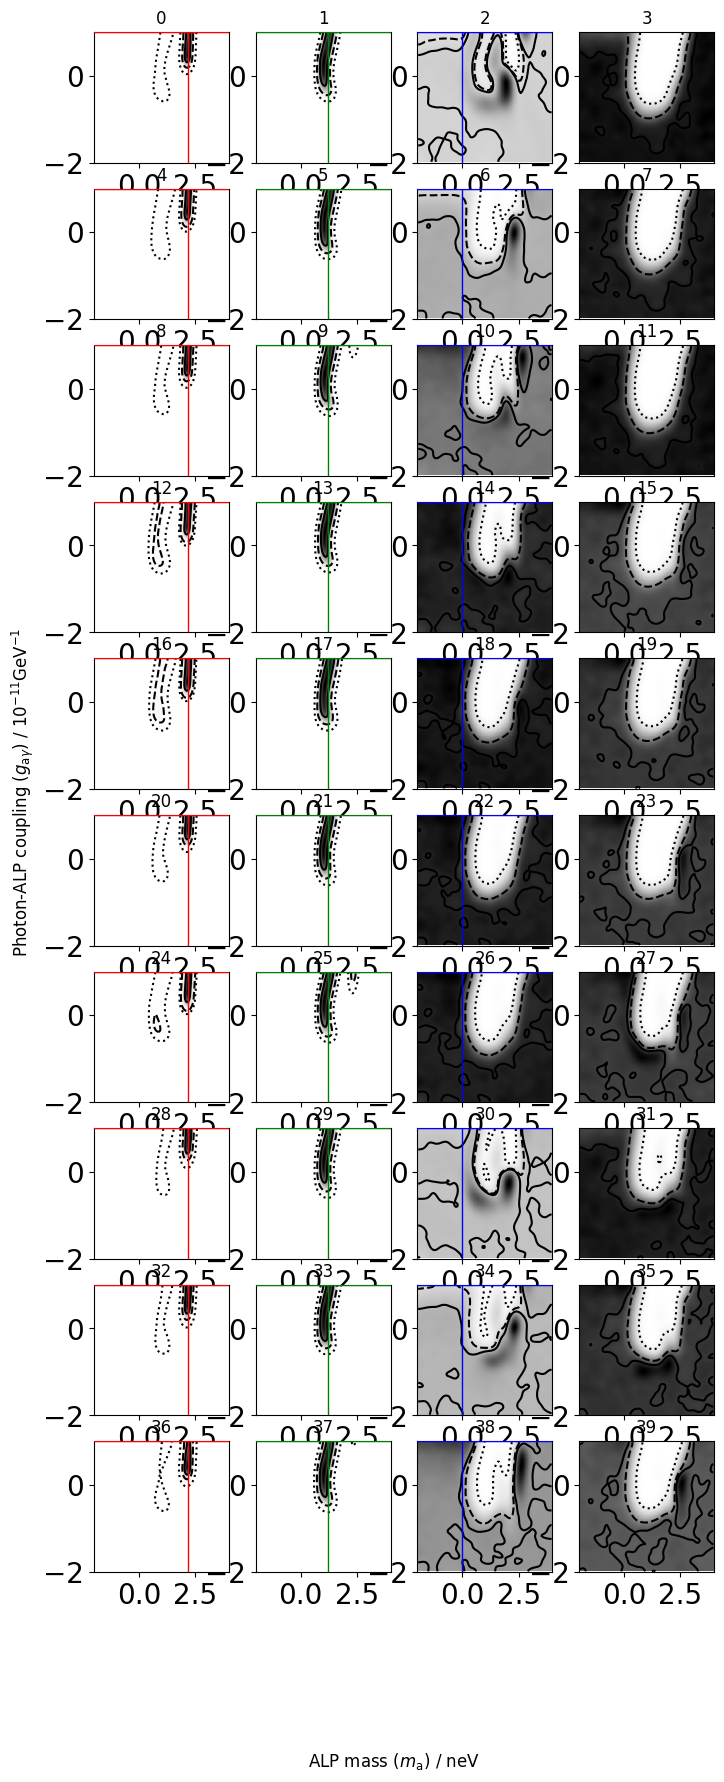

In [16]:
# dim = 10
# prior_type = 'confident1'
# names_selection = ['flare3_'+prior_type,'flare2_'+prior_type,'flare1_'+prior_type,'flare0_'+prior_type]
# len_names = len(names_selection)
# data = []
# data_temp = []
# logratios = []
# logratios_temp = []

# for i in range(dim):
#     for name in names_selection:
#         data_temp.append(copy.copy(priors[name]['samples_same_nuisance'][i]))
#         logratios_temp.extend(prepare_logratios(name,data_temp[-1:]))

# data = data_temp
logratios = logratios_temp


colors_data=['r']*len(data)
for i in range(len(colors_data)):
    if i%len_names == 0: 
        colors_data[i] = 'r'
    elif i%len_names == 1: 
        colors_data[i] = 'g'
    elif i%len_names == 2:
        colors_data[i] = 'b'
    elif i%len_names == 3:
        colors_data[i] = 'c'
linestyles_data=['-']*len(data)
# for i in range(len(colors_data)):
#     if i in [0,3,6]: 
#         linestyles_data[i] = ':'
#     elif i in [1,4,7]: 
#         linestyles_data[i] = '-'
#     elif i in [2,5,8]:
#         linestyles_data[i] = '--'

fig = plt.figure(figsize=(8,(8/len(names_selection))*np.ceil(len(data)/len(names_selection))))
for i in range(len(data)): 
    fig.add_subplot(int(np.ceil(len(data)/len(names_selection))),len(names_selection),i+1)
    fig.axes[-1].set_title(str(i))
    # if i <= (len(names_selection)-1)*(dim)-1:
    #     fig.axes[-1].set_xticks([])
    # else:
    #     fig.axes[-1].set_xticks([ms[i-(len(names_selection)-1)*(dim)]])
    # if i%dim != 0:
    #     fig.axes[-1].set_yticks([])
    # else:
    #     fig.axes[-1].set_yticks([gs[int(i/dim)]])
fig.supxlabel(xlabel)
fig.supylabel(ylabel)


plot_posteriors(name, logratios, data, axes = fig.axes, colors_truth = colors_data, linestyles_truth=linestyles_data)

for i in range(len(data)): 
    name = names_selection[i%len(names_selection)]
    fig.axes[i].set_xlim(priors[name]['bounds_rounds'][0][0][0])
    fig.axes[i].set_ylim(priors[name]['bounds_rounds'][0][0][1])




# fig_specs.supylabel('Residuals of log of Counts', fontsize=18)
# fig_specs.tight_layout()

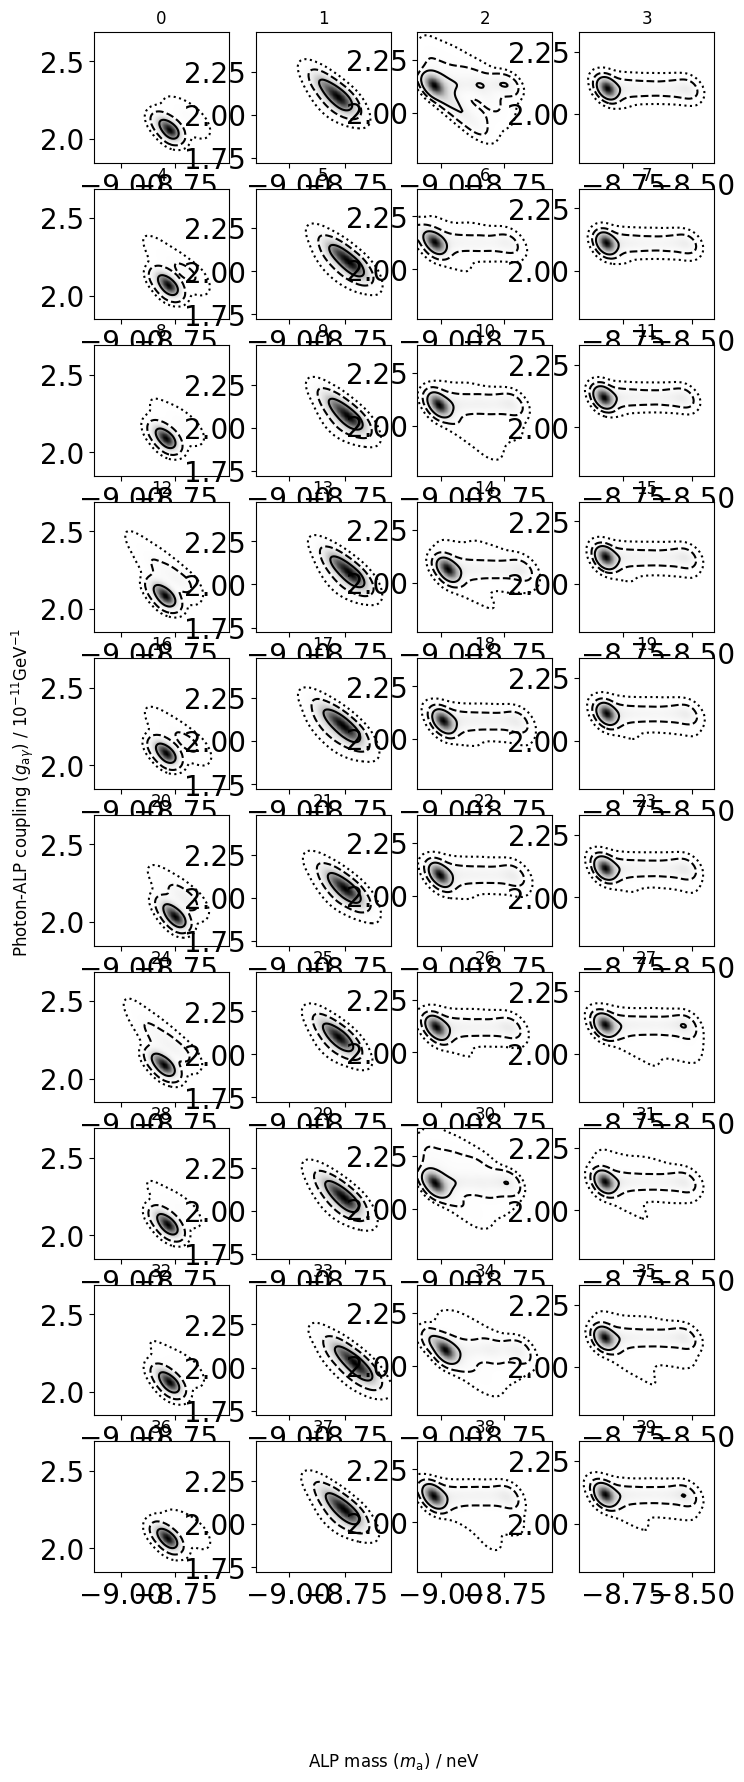

In [17]:
fig = plt.figure(figsize=(8,(8/len_names)*np.ceil(len(data)/len_names)))
for i in range(len(data)): 
    fig.add_subplot(int(np.ceil(len(data)/len_names)),len_names,i+1)
    fig.axes[-1].set_title(str(i))
fig.supxlabel(xlabel)
fig.supylabel(ylabel)
fig = plot_posteriors(name, logratios, data, axes = fig.axes, POIs=[2,3], colors_truth = colors_data, linestyles_truth=linestyles_data)

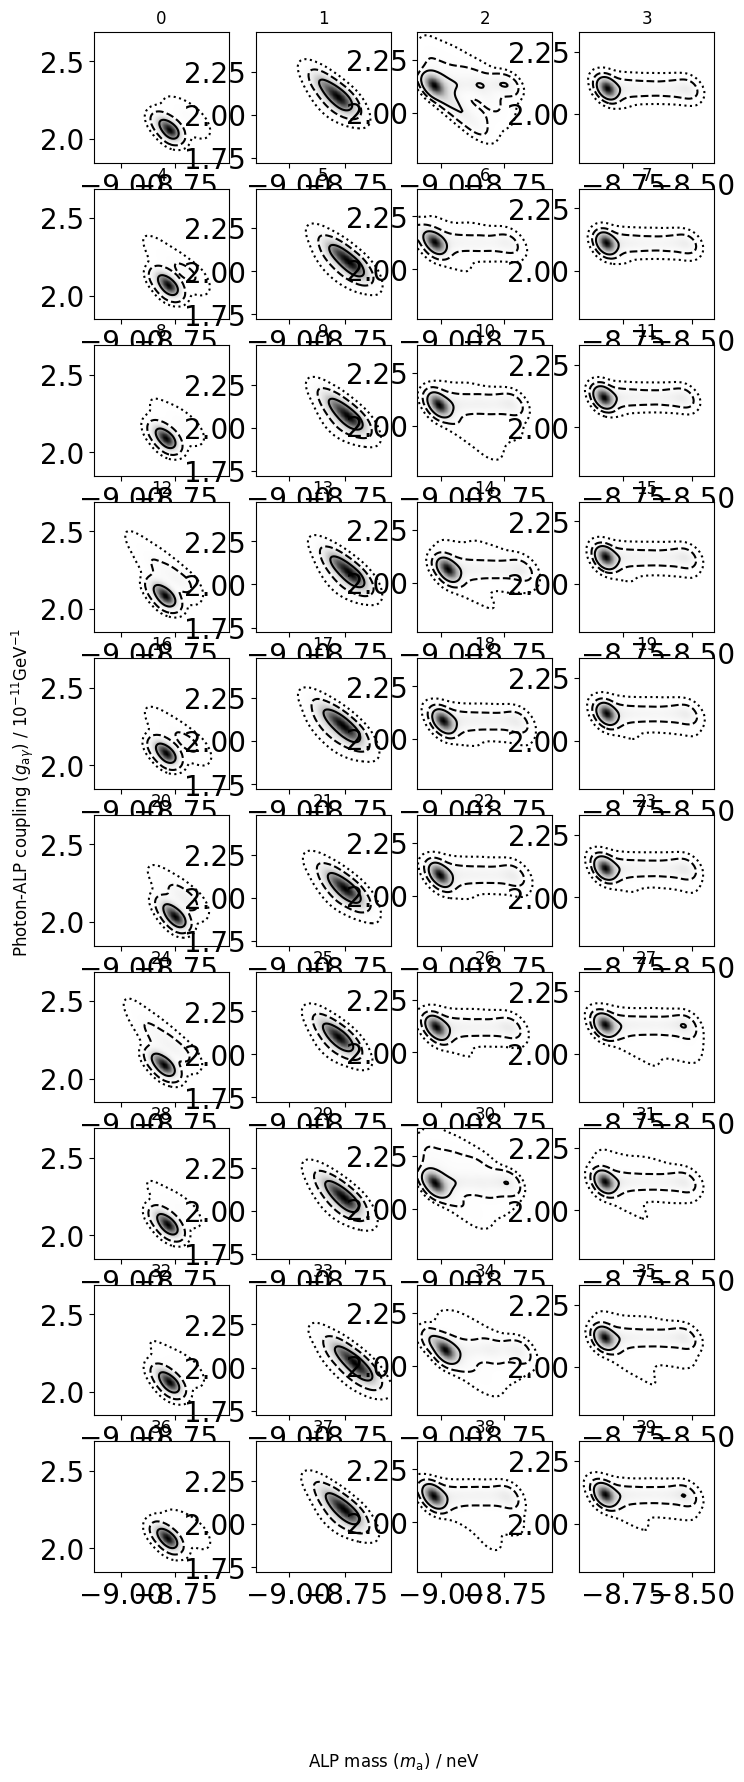

In [18]:
fig = plt.figure(figsize=(8,(8/len_names)*np.ceil(len(data)/len_names)))
for i in range(len(data)): 
    fig.add_subplot(int(np.ceil(len(data)/len_names)),len_names,i+1)
    fig.axes[-1].set_title(str(i))
fig.supxlabel(xlabel)
fig.supylabel(ylabel)
fig = plot_posteriors(name, logratios, data, axes = fig.axes, POIs=[2,3], colors_truth = colors_data, linestyles_truth=linestyles_data)

/home/gertwk/ALPs_with_SWYFT/cluster_runs/analysis_results/flare0_confident1/ALP_quick_sim.py:474: UserWarning: The number of model parameters, log-indicators, null-hypothesis parameters, parameter names and parameter units are not equal
  warnings.warn("The number of model parameters, log-indicators, null-hypothesis parameters, parameter names and parameter units are not equal")


Text(0.5, 1.0, 'Spectra leading to exclusions')

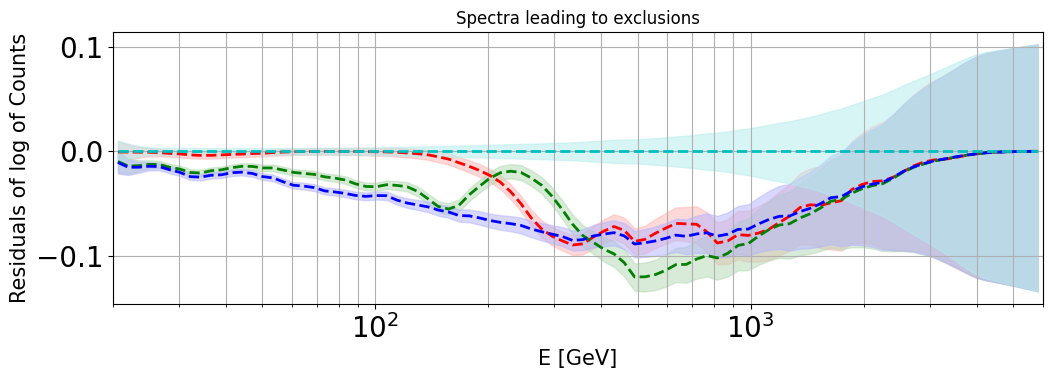

In [15]:
fig_specs = plt.figure(figsize=(12,12))

A = priors[name]['A']
fig_specs.add_subplot(3,1,1)
A.configure_plot(xmin=2e1, xmax=6e3, ymin=None,ymax=None,legend=0, logx=1, logy=0)
for i in range(len_names):
    A.configure_model(params=data[i]['params'])
    A.import_counts(obs=data[i]['data'],exp=data[i]['exp'])
    new_fig = 1 if i==0 else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color=colors_data[i],color_obs=colors_data[i],linestyle_obs=linestyles_data[i], 
                   linestyle="--",axes=fig_specs.axes[-1],
                   label_exp=0,label_obs=False, errorbands=1, errors=False, plot_exp=1, plot_obs=0, transparency=0)
fig_specs.axes[-1].set_title('Spectra leading to exclusions')
# fig_specs.axes[-1].set_xlabel('')
# fig_specs.axes[-1].set_xticks([])
# fig_specs.axes[-1].set_ylabel('')